<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/LOKA_U4_TRANS_ANALYSE_R3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
# ============================================================
# ADVANCED TRANSFORMER UNIT-4 HEALTH ANALYSIS
# Electrical + Temperature + Fan Group 1/2 + ML + Aging + Anomaly
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False


In [60]:

# ============================================================
# 1) FILE PATHS - UNIT 4
# ============================================================

elec_path = Path(r"/content/u4_electrical_20_5_2026_R1_2.csv")
temp_path = Path(r"/content/u4_trans_temp_20_5_2026_R1_2.csv")

fan1_path = Path(r"/content/fan_group1_u4_R1.xls")
fan2_path = Path(r"/content/fan_group2_u4_R1.xls")

output_excel = "Transformer_U4_Advanced_Status_Report.xlsx"

# Approximation because real ambient temperature is not available
AMBIENT_TEMP_C = 25

# Adjust if Unit 4 transformer rating is different
TRANSFORMER_RATED_MVA = 190


In [61]:
# ============================================================
# 2) HELPER FUNCTIONS
# ============================================================

def read_xls_safely(path):
    try:
        return pd.read_excel(path)
    except Exception:
        outdir = path.parent
        subprocess.run([
            "libreoffice", "--headless", "--convert-to", "xlsx",
            "--outdir", str(outdir), str(path)
        ], check=True)
        return pd.read_excel(path.with_suffix(".xlsx"))


def process_fan_file(path, group_name):
    fan = read_xls_safely(path)

    time_col = None
    for col in fan.columns:
        if "time" in col.lower() or "date" in col.lower():
            time_col = col
            break

    if time_col is None:
        time_col = fan.columns[0]

    desc_col = fan.columns[-1]

    fan["Timestamp"] = pd.to_datetime(
        fan[time_col],
        errors="coerce",
        dayfirst=True
    )

    fan = fan.dropna(subset=["Timestamp"]).sort_values("Timestamp")

    text = fan[desc_col].astype(str)

    fan[group_name] = np.where(
        text.str.contains("N-ACTIVE -> ACTIVE", case=False, na=False) |
        text.str.contains("OFF -> ON", case=False, na=False) |
        text.str.contains("0 -> 1", case=False, na=False),
        1,
        np.where(
            text.str.contains("ACTIVE -> N-ACTIVE", case=False, na=False) |
            text.str.contains("ON -> OFF", case=False, na=False) |
            text.str.contains("1 -> 0", case=False, na=False),
            0,
            np.nan
        )
    )

    fan = fan.dropna(subset=[group_name])

    return fan[["Timestamp", group_name]]


def normalize_bad(value, good, bad):
    score = 100 - ((value - good) / (bad - good) * 100)
    return np.clip(score, 0, 100)


In [62]:

# ============================================================
# 3) READ DATA
# ============================================================

elec = pd.read_csv(elec_path)
temp = pd.read_csv(temp_path, encoding='utf-16', sep='\t')

elec["Timestamp"] = pd.to_datetime(elec["Timestamp"], errors="coerce", dayfirst=True)
temp["Timestamp"] = pd.to_datetime(temp["Timestamp"], errors="coerce", dayfirst=True)

elec = elec.dropna(subset=["Timestamp"]).sort_values("Timestamp")
temp = temp.dropna(subset=["Timestamp"]).sort_values("Timestamp")

In [63]:
import pandas as pd
import numpy as np
import warnings

# ============================================================
# 4) RENAME UNIT 4 COLUMNS
# ============================================================

elec = elec.rename(columns={
    "ACTIVE POWER MEAS VALUE": "MW",
    "REACTIVE POWER MEAS VALUE": "MVAr",

    "VOLTAGE PHASE AB": "HV_AB_kV",
    "VOLTAGE PHASE BC": "HV_BC_kV",
    "VOLTAGE PHASE CA": "HV_CA_kV",

    "UNIT VOLTAGE PHASE AB": "LV_AB_kV",
    "UNIT VOLTAGE PHASE BC": "LV_BC_kV",
    "UNIT VOLTAGE PHASE CA": "LV_CA_kV",

    "ADM BUSBAR VOLTAGE PHASE TO PHASE": "ADM_Busbar_kV",
    "UNIT FREQUENCY": "Frequency_Hz",
    "ADM TOTAL ACTIVE POWER": "ADM_Total_MW",
})

# Dynamic renaming for 'temp' to ensure consistent column names
rename_map_temp = {}

# --- Identify Oil Temperature Column ---
oil_temp_col_to_rename = None
# Check if the target 'Oil_Temp_C' already exists (e.g., if cell was run before)
if "Oil_Temp_C" in temp.columns:
    oil_temp_col_to_rename = "Oil_Temp_C"
# Prioritize specific known original name for oil temp
elif "UNIT-4 TR 33 KV WINDING TEMPERATURE" in temp.columns:
    oil_temp_col_to_rename = "UNIT-4 TR 33 KV WINDING TEMPERATURE"
else:
    # Fallback: search for a column containing "OIL" or "TEMP" but NOT "WINDING"
    # This ensures we don't accidentally pick up winding temp columns as oil temp
    for col in temp.columns:
        col_upper = col.upper()
        if ("OIL" in col_upper or "TEMP" in col_upper) and "WINDING" not in col_upper and col != "Timestamp":
            oil_temp_col_to_rename = col
            break

if oil_temp_col_to_rename:
    # Only add to rename map if it's not already 'Oil_Temp_C'
    if oil_temp_col_to_rename != "Oil_Temp_C":
        rename_map_temp[oil_temp_col_to_rename] = "Oil_Temp_C"
elif "Oil_Temp_C" not in temp.columns: # If not found at all (original or renamed)
    raise KeyError("Could not identify the oil temperature column. Please inspect 'temp.columns' for its actual name.")

# --- Identify Winding Temperature Columns ---
# Use explicit list of known original winding temperature column names
winding_temp_original_candidates = [
    "UNIT-4 TR 33 KV WINDING TEMPERATURE.1",
    "UNIT-4 TR 33 KV WINDING TEMPERATURE.2",
    "04BAT10_CT021_XQ01(°C)"
]
found_winding_temp_cols_to_rename = []

# First, check if the target 'Winding_Temp_X_C' columns already exist
all_target_winding_exist = True
for i in range(1, 4):
    if f"Winding_Temp_{i}_C" not in temp.columns:
        all_target_winding_exist = False
        break

if all_target_winding_exist: # If already renamed, don't try to rename again
    pass # No action needed, columns are already in desired state
else:
    for col in winding_temp_original_candidates:
        if col in temp.columns:
            found_winding_temp_cols_to_rename.append(col)

    found_winding_temp_cols_to_rename.sort() # Sort for consistent naming to _1, _2, _3

    if len(found_winding_temp_cols_to_rename) == 3:
        for i, original_name in enumerate(found_winding_temp_cols_to_rename):
            rename_map_temp[original_name] = f"Winding_Temp_{i+1}_C"
    elif len(found_winding_temp_cols_to_rename) > 0:
        warnings.warn(
            f"Found {len(found_winding_temp_cols_to_rename)} winding temperature candidates from the expected original names, "
            "but expected 3. Renaming available ones as Winding_Temp_1_C, Winding_Temp_2_C etc."
            "Please check the raw 'temp' data columns if 'Winding_Temp_X_C' columns are missing later."
        )
        for i, original_name in enumerate(found_winding_temp_cols_to_rename):
            rename_map_temp[original_name] = f"Winding_Temp_{i+1}_C"
    else:
        raise KeyError(
            f"Expected 3 winding temperature columns from candidates {winding_temp_original_candidates}, "
            f"but found {len(found_winding_temp_cols_to_rename)}: {found_winding_temp_cols_to_rename}. "
            "Please inspect 'temp.columns' for actual winding temperature names."
        )

# Apply the renaming
temp = temp.rename(columns=rename_map_temp)

# Final checks after all renaming operations
if "Oil_Temp_C" not in temp.columns:
    raise KeyError("Oil_Temp_C column is still missing after renaming. Review temp DataFrame columns and renaming logic.")

expected_winding_cols_final = ["Winding_Temp_1_C", "Winding_Temp_2_C", "Winding_Temp_3_C"]
missing_winding_final = [col for col in expected_winding_cols_final if col not in temp.columns]
if missing_winding_final:
    raise KeyError(f"Winding temperature columns {missing_winding_final} are still missing after renaming. Review temp DataFrame columns and renaming logic.")

In [64]:
# ============================================================
# 5) MERGE ELECTRICAL + TEMPERATURE
# ============================================================

df = pd.merge_asof(
    elec.sort_values("Timestamp"),
    temp.sort_values("Timestamp"),
    on="Timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("10min")
)

# Ensure 'Oil_Temp_C' column exists before dropping NaNs
if "Oil_Temp_C" not in df.columns:
    found_oil_col = None
    for col in df.columns:
        if "OIL" in col.upper() and "TEMP" in col.upper():
            found_oil_col = col
            break
    if found_oil_col:
        df = df.rename(columns={found_oil_col: "Oil_Temp_C"})
    else:
        raise KeyError("Failed to identify and rename the oil temperature column to 'Oil_Temp_C'.")

# Ensure Winding Temperature Columns are Present
expected_winding_cols = ["Winding_Temp_1_C", "Winding_Temp_2_C", "Winding_Temp_3_C"]
missing_from_df = [col for col in expected_winding_cols if col not in df.columns]

if missing_from_df:
    # Check if 'temp' still has these columns (it should, based on previous fix)
    temp_winding_cols_exist = all(col in temp.columns for col in expected_winding_cols)

    if temp_winding_cols_exist:
        warnings.warn(
            f"Winding temperature columns {missing_from_df} were missing from 'df' after initial merge. "
            "Attempting to re-merge them from 'temp'. This indicates a potential issue with the primary merge_asof or timestamp alignment."
        )
        # Perform a targeted merge for the winding temperature columns
        df = pd.merge_asof(
            df.sort_values("Timestamp"),
            temp[["Timestamp"] + expected_winding_cols].sort_values("Timestamp"),
            on="Timestamp",
            direction="nearest",
            tolerance=pd.Timedelta("10min")
        )
        # After re-merge, re-check for any remaining missing columns
        final_missing = [col for col in expected_winding_cols if col not in df.columns]
        if final_missing:
            raise KeyError(f"Even after re-merging, winding temperature columns {final_missing} are still missing from 'df'. There is a critical issue with data integration.")
    else:
        raise KeyError(
            f"Winding temperature columns {missing_from_df} are missing from 'df' and "
            "also unexpectedly not found in 'temp' DataFrame. Check previous renaming steps."
        )

df = df.dropna(subset=["MW", "Oil_Temp_C"]).sort_values("Timestamp")
df = df[df["MW"] >= 0]

In [65]:
# ============================================================
# 6) FAN GROUP 1 + FAN GROUP 2
# ============================================================

fan1 = process_fan_file(fan1_path, "Fan_Group_1_Status")
fan2 = process_fan_file(fan2_path, "Fan_Group_2_Status")

df = pd.merge_asof(
    df.sort_values("Timestamp"),
    fan1.sort_values("Timestamp"),
    on="Timestamp",
    direction="backward"
)

df = pd.merge_asof(
    df.sort_values("Timestamp"),
    fan2.sort_values("Timestamp"),
    on="Timestamp",
    direction="backward"
)

df["Fan_Group_1_Status"] = df["Fan_Group_1_Status"].fillna(0)
df["Fan_Group_2_Status"] = df["Fan_Group_2_Status"].fillna(0)

df["Total_Fan_Groups_ON"] = (
    df["Fan_Group_1_Status"] +
    df["Fan_Group_2_Status"]
)


In [78]:
# ============================================================
# 7) BASIC ELECTRICAL KPIs
# ============================================================

df["ApparentPower_MVA"] = np.sqrt(df["MW"]**2 + df["MVAr"]**2)
df["Load_Percent"] = df["ApparentPower_MVA"] / TRANSFORMER_RATED_MVA * 100
df["PowerFactor"] = df["MW"] / df["ApparentPower_MVA"].replace(0, np.nan)

df["HV_avg_kV"] = df[["HV_AB_kV", "HV_BC_kV", "HV_CA_kV"]].mean(axis=1)

df["HV_imbalance_percent"] = (
    df[["HV_AB_kV", "HV_BC_kV", "HV_CA_kV"]]
    .sub(df["HV_avg_kV"], axis=0)
    .abs()
    .max(axis=1)
    / df["HV_avg_kV"] * 100
)

df["LV_avg_kV"] = df[["LV_AB_kV", "LV_BC_kV", "LV_CA_kV"]].mean(axis=1)

df["LV_imbalance_percent"] = (
    df[["LV_AB_kV", "LV_BC_kV", "LV_CA_kV"]]
    .sub(df["LV_avg_kV"], axis=0)
    .abs()
    .max(axis=1)
    / df["LV_avg_kV"] * 100
)

# ============================================================
# 7B) 33kV SIDE IMBALANCE vs ADM TOTAL ACTIVE POWER
# ============================================================

# 33kV side voltage imbalance
df["LV_33kV_avg_kV"] = df[["LV_AB_kV", "LV_BC_kV", "LV_CA_kV"]].mean(axis=1)

df["LV_33kV_Imbalance_percent"] = (
    df[["LV_AB_kV", "LV_BC_kV", "LV_CA_kV"]]
    .sub(df["LV_33kV_avg_kV"], axis=0)
    .abs()
    .max(axis=1)
    / df["LV_33kV_avg_kV"] * 100
)

# Use ADM total active power if available
if "ADM_Total_MW" in df.columns:
    df["ADM_MW_Bin"] = (df["ADM_Total_MW"] / 2).round() * 2

    adm_imbalance_summary = (
        df.groupby("ADM_MW_Bin")
        .agg({
            "ADM_Total_MW": ["count", "mean"],
            "LV_33kV_Imbalance_percent": ["mean", "max", "std"],
            "LV_AB_kV": "mean",
            "LV_BC_kV": "mean",
            "LV_CA_kV": "mean",
            "MW": "mean",
            "ApparentPower_MVA": "mean"
        })
    )

    adm_imbalance_summary.columns = [
        "_".join(col).strip()
        for col in adm_imbalance_summary.columns.values
    ]

    adm_imbalance_summary = adm_imbalance_summary.reset_index()

    # remove weak bins
    adm_imbalance_summary = adm_imbalance_summary[
        adm_imbalance_summary["ADM_Total_MW_count"] >= 5
    ]

    print("\n========== 33kV IMBALANCE vs ADM TOTAL MW ==========")
    print(adm_imbalance_summary)


========== 33kV IMBALANCE vs ADM TOTAL MW ==========
    ADM_MW_Bin  ADM_Total_MW_count  ADM_Total_MW_mean  \
0         -0.0                 489          -0.056087   
1          2.0                  62           1.859785   
2          4.0                  48           3.771389   
3          6.0                  30           5.919271   
4          8.0                  16           7.899167   
5         10.0                  20          10.126667   
6         12.0                  19          11.963859   
7         14.0                  15          14.220889   
8         16.0                  12          16.041666   
9         18.0                  12          18.062778   
10        20.0                  19          20.032282   
11        22.0                  11          21.991516   
12        24.0                  22          23.934849   
13        26.0                  20          25.997332   
14        28.0                  13          27.963078   
15        30.0                  19

In [67]:
# ============================================================
# 8) THERMAL KPIs
# ============================================================

df["Winding_Avg_C"] = df[
    ["Winding_Temp_1_C", "Winding_Temp_2_C", "Winding_Temp_3_C"]
].mean(axis=1)

df["Winding_Max_C"] = df[
    ["Winding_Temp_1_C", "Winding_Temp_2_C", "Winding_Temp_3_C"]
].max(axis=1)

df["Winding_Spread_C"] = (
    df[["Winding_Temp_1_C", "Winding_Temp_2_C", "Winding_Temp_3_C"]].max(axis=1)
    -
    df[["Winding_Temp_1_C", "Winding_Temp_2_C", "Winding_Temp_3_C"]].min(axis=1)
)

df["Ambient_Temp_C"] = AMBIENT_TEMP_C

df["Oil_Rise_Over_Ambient_C"] = df["Oil_Temp_C"] - df["Ambient_Temp_C"]
df["Winding_Rise_Over_Ambient_C"] = df["Winding_Avg_C"] - df["Ambient_Temp_C"]

df["Winding_Oil_Gradient_C"] = df["Winding_Avg_C"] - df["Oil_Temp_C"]
df["MaxWinding_Oil_Gradient_C"] = df["Winding_Max_C"] - df["Oil_Temp_C"]

df["Cooling_Efficiency_KPI"] = (
    df["Oil_Rise_Over_Ambient_C"] /
    df["ApparentPower_MVA"].replace(0, np.nan)
)

df["Thermal_Load_Index"] = (
    df["Oil_Temp_C"] /
    df["ApparentPower_MVA"].replace(0, np.nan)
)

# ============================================================
# 8B) MW / MVA BIN THERMAL ANALYSIS
# ============================================================

# ----------------------------
# MW bins
# ----------------------------
mw_bin_size = 2

df["MW_Bin"] = (
    (df["MW"] / mw_bin_size).round() * mw_bin_size
)

# Define aggregation dictionary
agg_dict = {
    "MW": ["count", "mean"],
    "ApparentPower_MVA": "mean",

    "Oil_Temp_C": ["mean", "max", "std"],
    "Winding_Avg_C": ["mean", "max", "std"],
    "Winding_Max_C": ["mean", "max"],

    "Cooling_Efficiency_KPI": "mean",

    "HV_imbalance_percent": "mean",
    "LV_imbalance_percent": "mean",
}

# Conditionally add 'Advanced_Transformer_Health_Score' if it exists in df
if "Advanced_Transformer_Health_Score" in df.columns:
    agg_dict["Advanced_Transformer_Health_Score"] = "mean"

mw_bin_summary = (
    df.groupby("MW_Bin")
    .agg(agg_dict)
)

mw_bin_summary.columns = [
    "_".join(col).strip()
    for col in mw_bin_summary.columns.values
]

mw_bin_summary = mw_bin_summary.reset_index()

# Remove weak bins
mw_bin_summary = mw_bin_summary[
    mw_bin_summary["MW_count"] >= 5
]

print("\n========== MW BIN SUMMARY ==========")
print(mw_bin_summary.head())


========== MW BIN SUMMARY ==========
   MW_Bin  MW_count    MW_mean  ApparentPower_MVA_mean  Oil_Temp_C_mean  \
1    18.0        19  18.798318               19.681207        44.082636   
2    20.0        54  20.191870               21.388731        40.574812   
3    22.0       155  22.363535               22.975612        41.973037   
4    24.0       221  24.048266               24.556280        41.003068   
5    26.0       232  26.026829               26.624904        41.810871   

   Oil_Temp_C_max  Oil_Temp_C_std  Winding_Avg_C_mean  Winding_Avg_C_max  \
1        53.68695        4.830159           31.176674          38.480767   
2        51.48692        4.801702           28.535067          35.278800   
3        51.48647        4.135638           29.916005          36.688810   
4        54.28363        4.641767           29.319737          38.205483   
5        54.84583        5.122030           29.828255          38.701450   

   Winding_Avg_C_std  Winding_Max_C_mean  Winding_Max_

In [68]:
# ============================================================
# 9) DYNAMIC THERMAL FEATURES
# ============================================================

df = df.sort_values("Timestamp")

for lag in [1, 2, 3, 6, 12]:
    df[f"MW_lag_{lag}"] = df["MW"].shift(lag)
    df[f"MVA_lag_{lag}"] = df["ApparentPower_MVA"].shift(lag)
    df[f"OilTemp_lag_{lag}"] = df["Oil_Temp_C"].shift(lag)
    df[f"WindingTemp_lag_{lag}"] = df["Winding_Avg_C"].shift(lag)

df["MW_rolling_6_mean"] = df["MW"].rolling(6).mean()
df["MVA_rolling_6_mean"] = df["ApparentPower_MVA"].rolling(6).mean()
df["OilTemp_rolling_6_mean"] = df["Oil_Temp_C"].rolling(6).mean()
df["WindingTemp_rolling_6_mean"] = df["Winding_Avg_C"].rolling(6).mean()

df["OilTemp_Rate_C_per_sample"] = df["Oil_Temp_C"].diff()
df["WindingTemp_Rate_C_per_sample"] = df["Winding_Avg_C"].diff()

In [69]:

# ============================================================
# 10) AGING / REMAINING LIFE ESTIMATION
# ============================================================

df["Estimated_Hotspot_C"] = df["Winding_Max_C"] + 10

df["Aging_Acceleration_Factor"] = np.exp(
    (15000 / 383) - (15000 / (df["Estimated_Hotspot_C"] + 273))
)

df["Equivalent_Aging_Hours"] = df["Aging_Acceleration_Factor"]
df["Cumulative_Aging_Hours"] = df["Equivalent_Aging_Hours"].cumsum()

df["Life_Consumption_Percent"] = (
    df["Cumulative_Aging_Hours"] / 180000 * 100
)



In [70]:
# ============================================================
# 11) FAST ML PREDICTION MODEL
# Predict winding average temperature
# ============================================================

feature_cols = [
    "MW", "MVAr", "ApparentPower_MVA", "Load_Percent", "PowerFactor",
    "HV_imbalance_percent", "LV_imbalance_percent",
    "Oil_Temp_C", "Ambient_Temp_C",
    "Fan_Group_1_Status", "Fan_Group_2_Status", "Total_Fan_Groups_ON",

    "MW_lag_1", "MW_lag_2", "MW_lag_3", "MW_lag_6",
    "MVA_lag_1", "MVA_lag_2", "MVA_lag_3", "MVA_lag_6",
    "OilTemp_lag_1", "OilTemp_lag_2", "OilTemp_lag_3", "OilTemp_lag_6",

    "MW_rolling_6_mean",
    "MVA_rolling_6_mean",
    "OilTemp_rolling_6_mean"
]

model_df = df.dropna(subset=feature_cols + ["Winding_Avg_C"]).copy()

# Optional: reduce very large dataset size for speed
MAX_ROWS_FOR_ML = 30000

if len(model_df) > MAX_ROWS_FOR_ML:
    model_df = model_df.iloc[::max(1, len(model_df)//MAX_ROWS_FOR_ML)].copy()

X = model_df[feature_cols]
y = model_df["Winding_Avg_C"]

split_index = int(len(model_df) * 0.75)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=80,       # reduced from 300
        max_depth=8,           # reduced from 12
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
}

# Use XGBoost only if dataset is not too large
if XGB_AVAILABLE and len(model_df) < 20000:
    models["XGBoost"] = XGBRegressor(
        n_estimators=120,      # reduced from 400
        max_depth=3,           # reduced from 5
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=2
    )

metrics_rows = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    metrics_rows.append({
        "Model": name,
        "Train_R2": r2_score(y_train, train_pred),
        "Test_R2": r2_score(y_test, test_pred),
        "Train_MAE_C": mean_absolute_error(y_train, train_pred),
        "Test_MAE_C": mean_absolute_error(y_test, test_pred),
        "Train_RMSE_C": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test_RMSE_C": np.sqrt(mean_squared_error(y_test, test_pred)),
    })

    model_df[f"{name}_Predicted_Winding_C"] = model.predict(X)
    model_df[f"{name}_Residual_C"] = (
        model_df["Winding_Avg_C"] -
        model_df[f"{name}_Predicted_Winding_C"]
    )

ml_metrics = pd.DataFrame(metrics_rows)

best_model_name = ml_metrics.sort_values("Test_MAE_C").iloc[0]["Model"]
best_pred_col = f"{best_model_name}_Predicted_Winding_C"
best_residual_col = f"{best_model_name}_Residual_C"

df = df.merge(
    model_df[["Timestamp", best_pred_col, best_residual_col]],
    on="Timestamp",
    how="left"
)

print("\nML model completed successfully")
print(ml_metrics)

Training RandomForest...
Training XGBoost...

ML model completed successfully
          Model  Train_R2   Test_R2  Train_MAE_C  Test_MAE_C  Train_RMSE_C  \
0  RandomForest  0.979411  0.786114     0.331215    0.845633      0.450543   
1       XGBoost  0.985721  0.834268     0.294020    0.765325      0.375206   

   Test_RMSE_C  
0     1.156484  
1     1.018009  


In [71]:

# ============================================================
# 12) ANOMALY DETECTION
# ============================================================

anomaly_features = [
    "MW", "MVAr", "ApparentPower_MVA",
    "Oil_Temp_C", "Winding_Avg_C", "Winding_Max_C",
    "Winding_Spread_C", "Winding_Oil_Gradient_C",
    "HV_imbalance_percent", "LV_imbalance_percent",
    "Cooling_Efficiency_KPI",
    "Total_Fan_Groups_ON"
]

anom_df = df.dropna(subset=anomaly_features).copy()

scaler = StandardScaler()
X_anom = scaler.fit_transform(anom_df[anomaly_features])

iso = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42
)

anom_df["Anomaly_Label"] = iso.fit_predict(X_anom)
anom_df["Anomaly_Score"] = iso.decision_function(X_anom)
anom_df["Is_Anomaly"] = np.where(anom_df["Anomaly_Label"] == -1, 1, 0)

df = df.merge(
    anom_df[["Timestamp", "Anomaly_Score", "Is_Anomaly"]],
    on="Timestamp",
    how="left"
)

df["Is_Anomaly"] = df["Is_Anomaly"].fillna(0)



In [72]:

# ============================================================
# 13) ADVANCED HEALTH SCORE
# ============================================================

df["Oil_Temp_Score"] = normalize_bad(df["Oil_Temp_C"], 60, 90)
df["Winding_Temp_Score"] = normalize_bad(df["Winding_Max_C"], 70, 110)
df["HV_Imbalance_Score"] = normalize_bad(df["HV_imbalance_percent"], 0.5, 2.0)
df["LV_Imbalance_Score"] = normalize_bad(df["LV_imbalance_percent"], 0.3, 1.5)
df["Cooling_Score"] = normalize_bad(df["Cooling_Efficiency_KPI"], 0.15, 0.40)
df["Aging_Score"] = normalize_bad(df["Aging_Acceleration_Factor"], 1.0, 5.0)
df["Winding_Spread_Score"] = normalize_bad(df["Winding_Spread_C"], 3, 10)

df["Anomaly_Score_Component"] = np.where(df["Is_Anomaly"] == 1, 60, 100)

df["Advanced_Transformer_Health_Score"] = (
    0.18 * df["Oil_Temp_Score"] +
    0.20 * df["Winding_Temp_Score"] +
    0.10 * df["HV_Imbalance_Score"] +
    0.05 * df["LV_Imbalance_Score"] +
    0.12 * df["Cooling_Score"] +
    0.15 * df["Aging_Score"] +
    0.10 * df["Winding_Spread_Score"] +
    0.10 * df["Anomaly_Score_Component"]
)



In [73]:

# ============================================================
# 14) SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Parameter": [
        "Average MW",
        "Maximum MW",
        "Average MVA",
        "Maximum MVA",
        "Average Load %",
        "Maximum Load %",
        "Average Oil Temp",
        "Maximum Oil Temp",
        "Average Winding Temp",
        "Maximum Winding Temp",
        "Average Winding Spread",
        "Maximum Winding Spread",
        "Average Cooling Efficiency KPI",
        "Maximum Cooling Efficiency KPI",
        "Average Aging Acceleration Factor",
        "Maximum Aging Acceleration Factor",
        "Estimated Life Consumption %",
        "Average HV Imbalance %",
        "Maximum HV Imbalance %",
        "Average LV Imbalance %",
        "Maximum LV Imbalance %",
        "Detected Anomaly Count",
        "Anomaly Percent",
        "Average Advanced Health Score",
        "Minimum Advanced Health Score"
    ],
    "Value": [
        df["MW"].mean(),
        df["MW"].max(),
        df["ApparentPower_MVA"].mean(),
        df["ApparentPower_MVA"].max(),
        df["Load_Percent"].mean(),
        df["Load_Percent"].max(),
        df["Oil_Temp_C"].mean(),
        df["Oil_Temp_C"].max(),
        df["Winding_Avg_C"].mean(),
        df["Winding_Max_C"].max(),
        df["Winding_Spread_C"].mean(),
        df["Winding_Spread_C"].max(),
        df["Cooling_Efficiency_KPI"].mean(),
        df["Cooling_Efficiency_KPI"].max(),
        df["Aging_Acceleration_Factor"].mean(),
        df["Aging_Acceleration_Factor"].max(),
        df["Life_Consumption_Percent"].max(),
        df["HV_imbalance_percent"].mean(),
        df["HV_imbalance_percent"].max(),
        df["LV_imbalance_percent"].mean(),
        df["LV_imbalance_percent"].max(),
        df["Is_Anomaly"].sum(),
        df["Is_Anomaly"].mean() * 100,
        df["Advanced_Transformer_Health_Score"].mean(),
        df["Advanced_Transformer_Health_Score"].min()
    ]
})

print("\n========== ML MODEL METRICS ==========")
print(ml_metrics)

print("\n========== UNIT 4 TRANSFORMER SUMMARY ==========")
print(summary)

avg_health = df["Advanced_Transformer_Health_Score"].mean()

if avg_health >= 85:
    status = "GOOD"
elif avg_health >= 70:
    status = "NORMAL / WATCH"
else:
    status = "ATTENTION REQUIRED"

print("\n========== FINAL UNIT 4 TRANSFORMER STATUS ==========")
print("Status:", status)
print(f"Average Advanced Health Score: {avg_health:.2f}")




========== ML MODEL METRICS ==========
          Model  Train_R2   Test_R2  Train_MAE_C  Test_MAE_C  Train_RMSE_C  \
0  RandomForest  0.979411  0.786114     0.331215    0.845633      0.450543   
1       XGBoost  0.985721  0.834268     0.294020    0.765325      0.375206   

   Test_RMSE_C  
0     1.156484  
1     1.018009  

========== UNIT 4 TRANSFORMER SUMMARY ==========
                            Parameter      Value
0                          Average MW  25.284393
1                          Maximum MW  31.844030
2                         Average MVA  25.827928
3                         Maximum MVA  32.219906
4                      Average Load %  13.593646
5                      Maximum Load %  16.957845
6                    Average Oil Temp  42.156411
7                    Maximum Oil Temp  54.845830
8                Average Winding Temp  30.249701
9                Maximum Winding Temp  54.807210
10             Average Winding Spread  32.031194
11             Maximum Winding Sprea

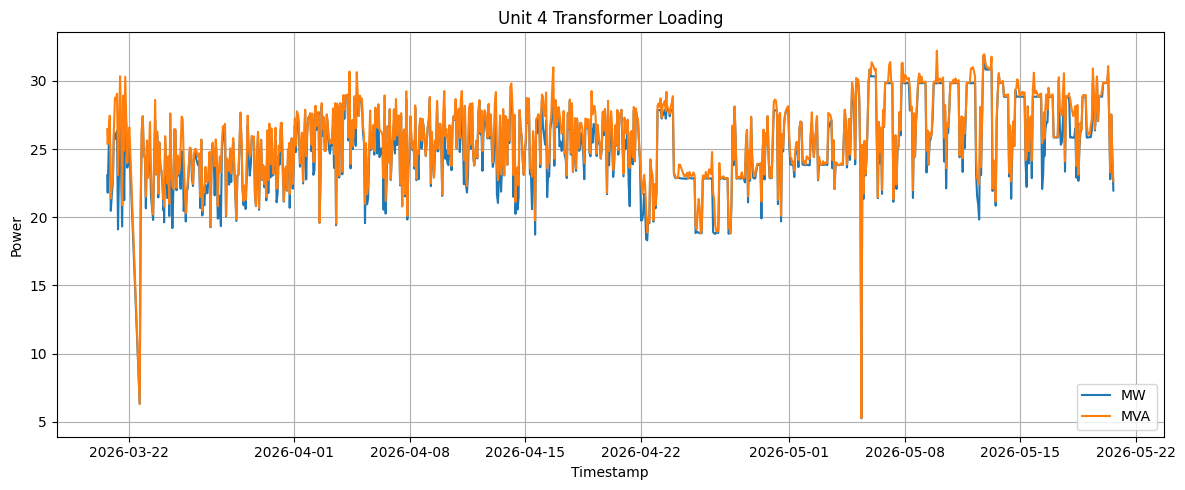

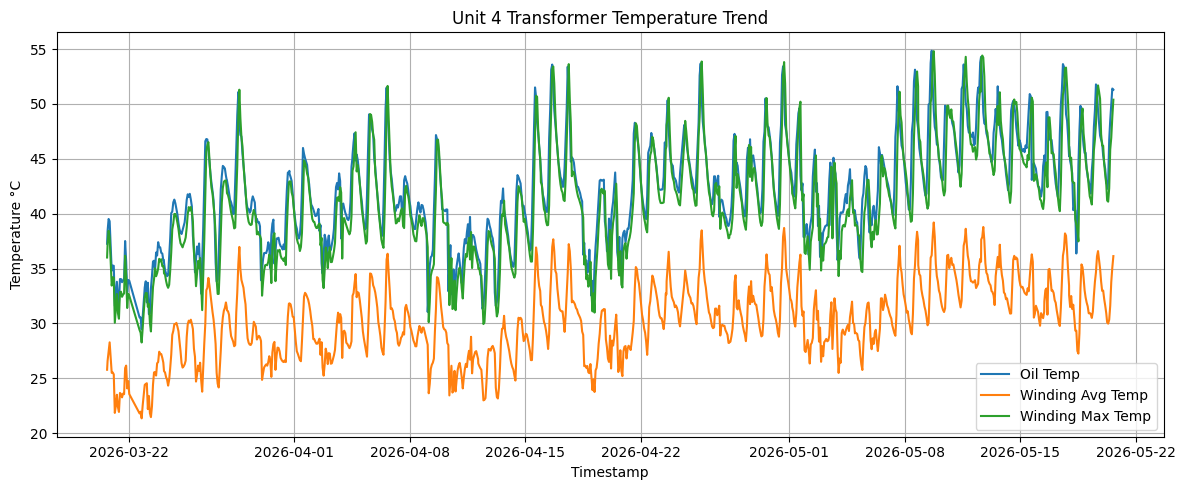

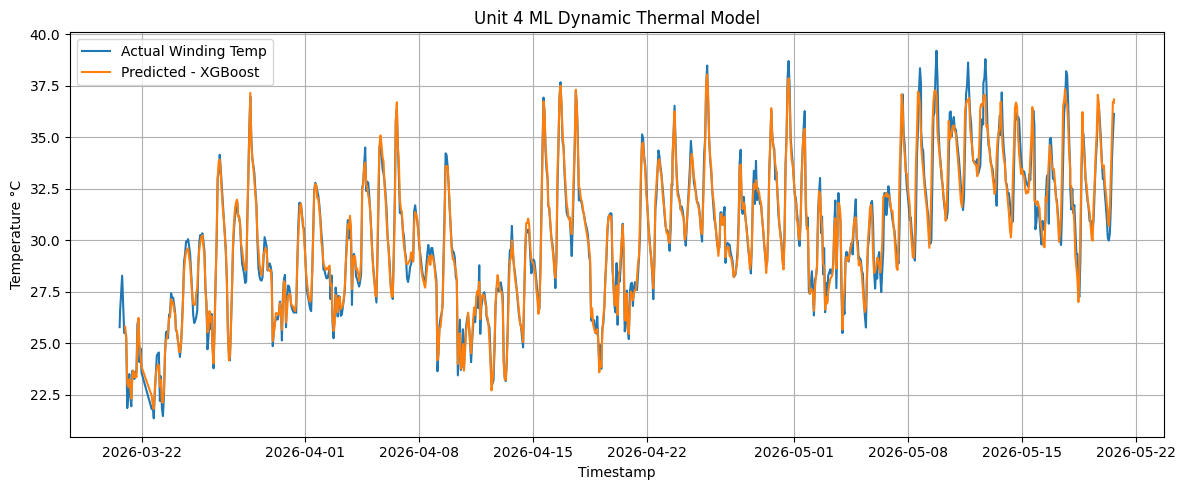

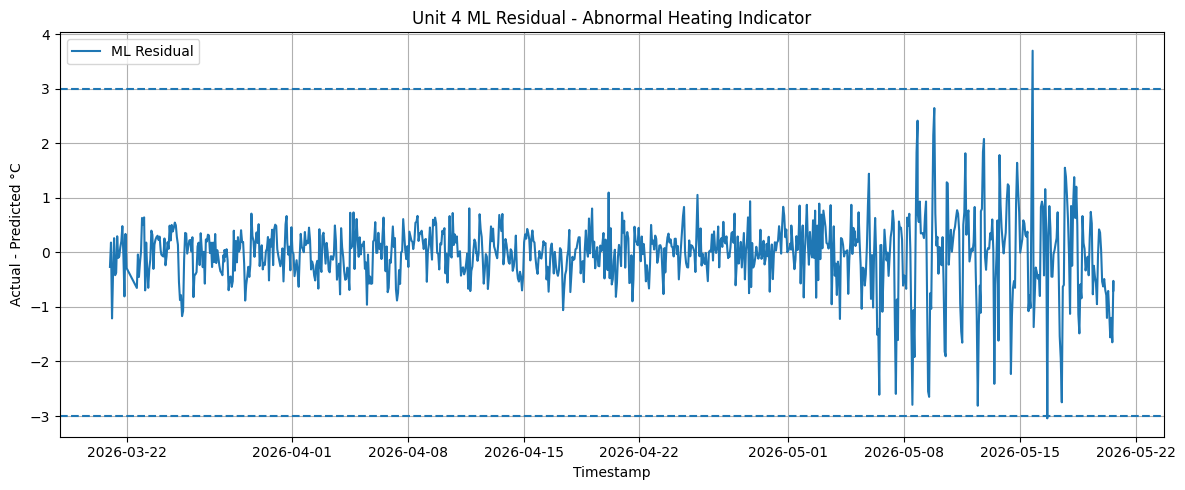

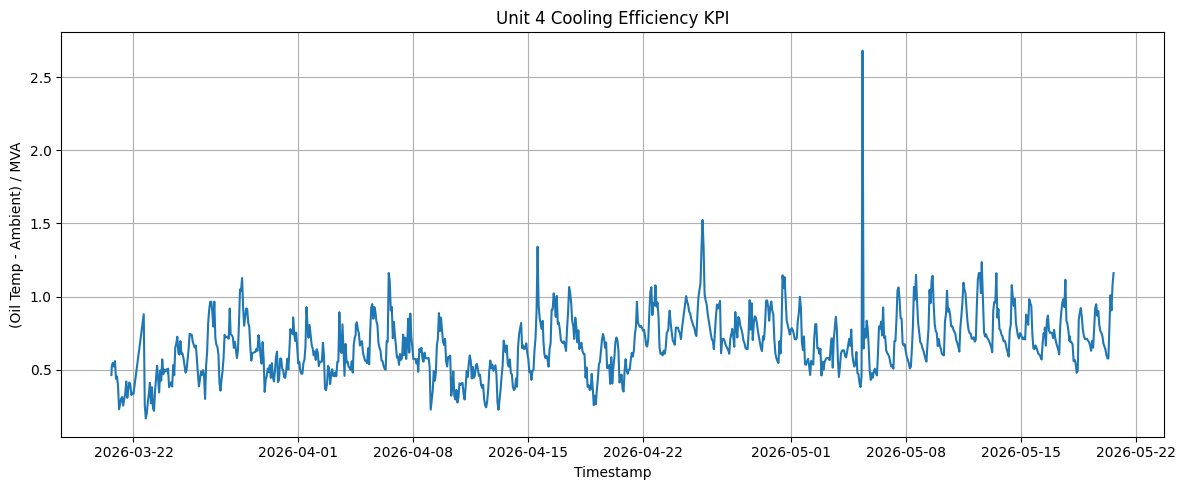

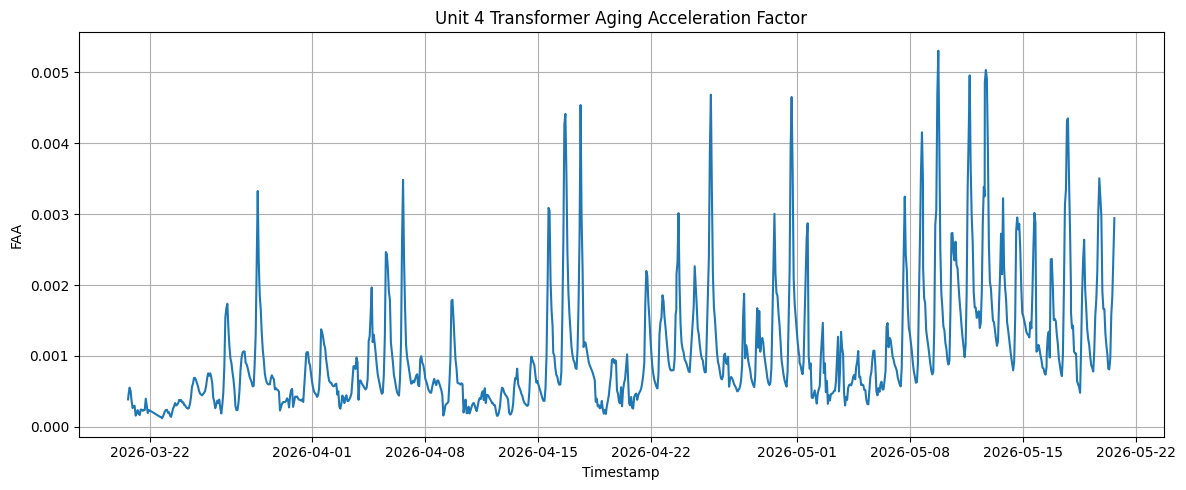

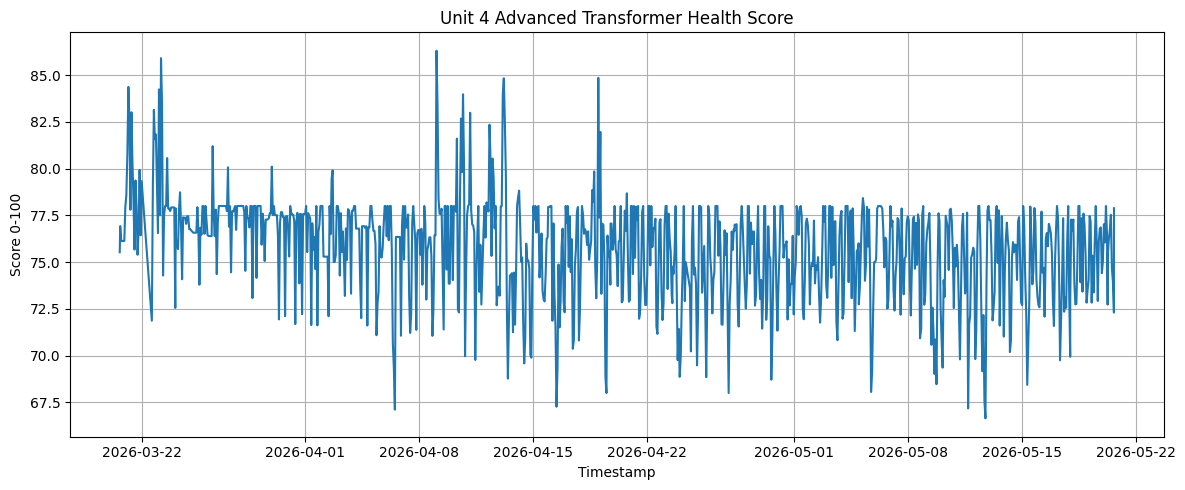

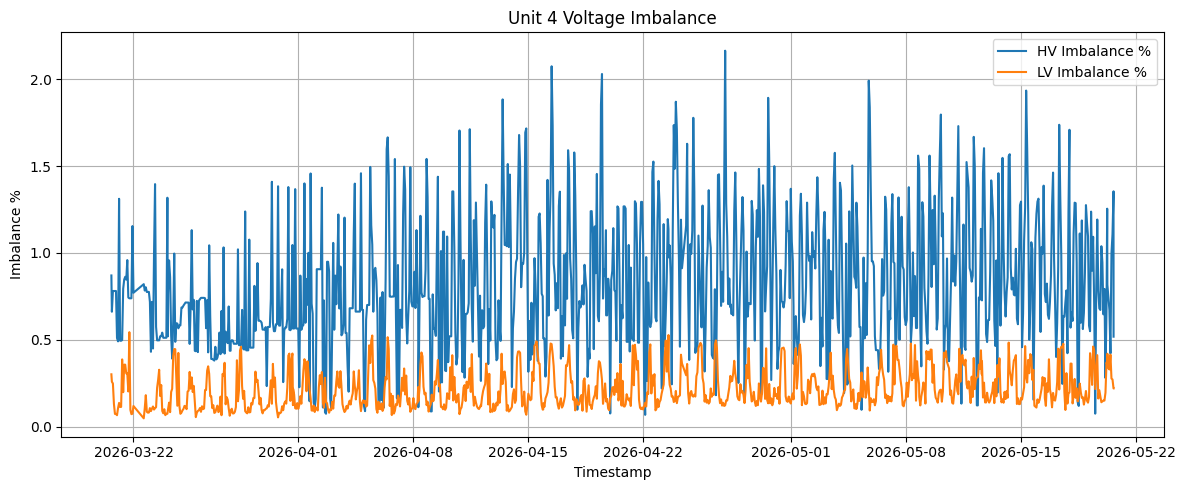

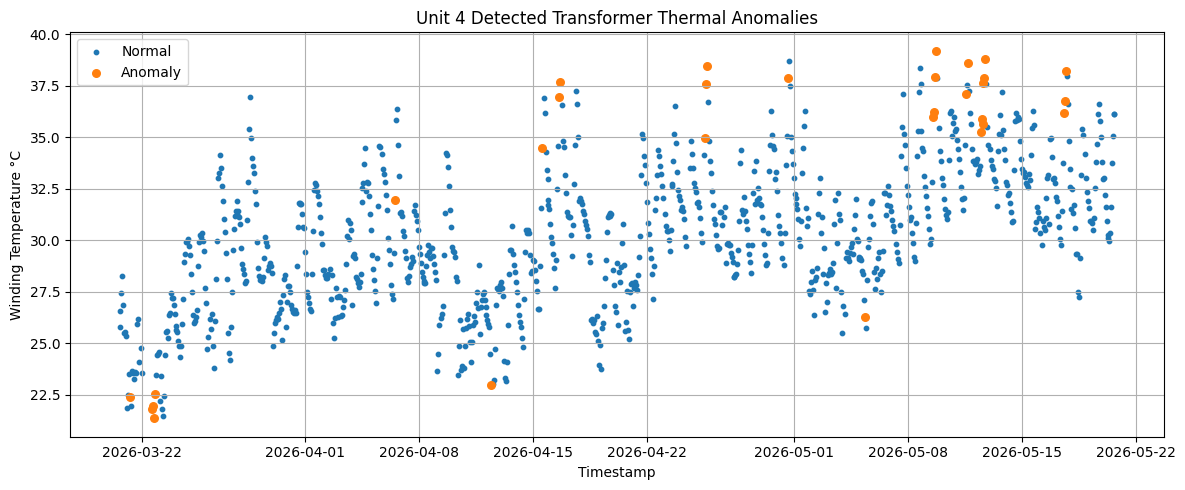

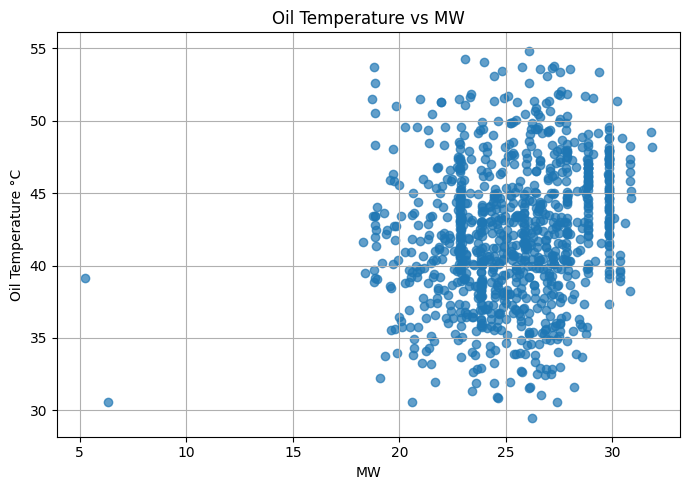

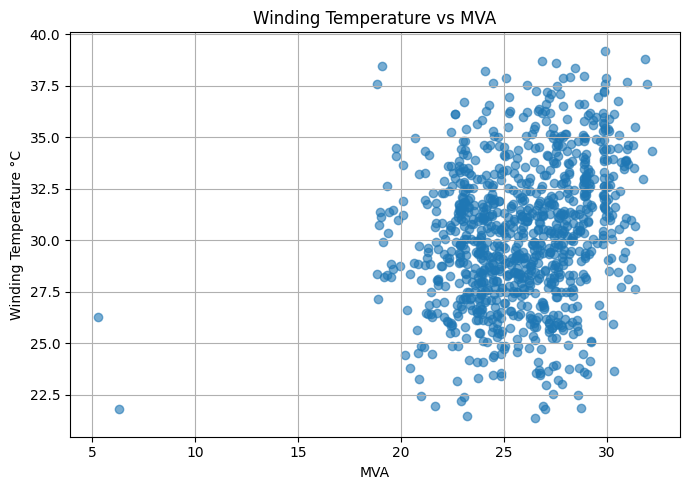

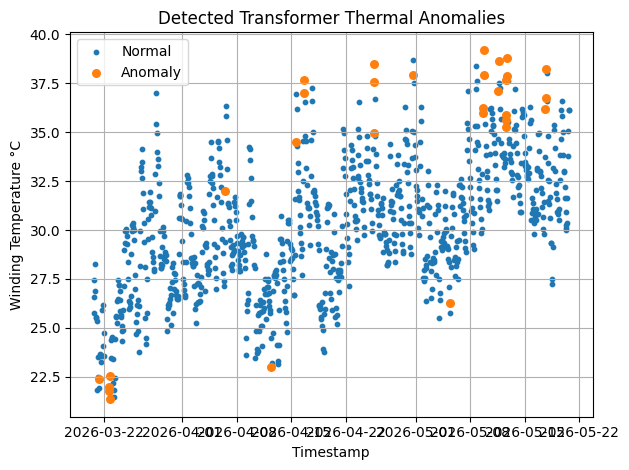

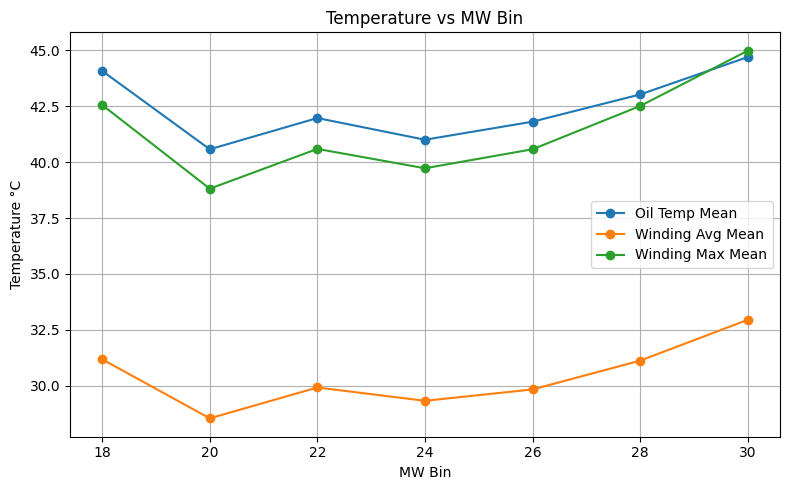

In [74]:

# ============================================================
# 15) PLOTS
# ============================================================

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["MW"], label="MW")
plt.plot(df["Timestamp"], df["ApparentPower_MVA"], label="MVA")
plt.title("Unit 4 Transformer Loading")
plt.xlabel("Timestamp")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["Oil_Temp_C"], label="Oil Temp")
plt.plot(df["Timestamp"], df["Winding_Avg_C"], label="Winding Avg Temp")
plt.plot(df["Timestamp"], df["Winding_Max_C"], label="Winding Max Temp")
plt.title("Unit 4 Transformer Temperature Trend")
plt.xlabel("Timestamp")
plt.ylabel("Temperature °C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["Winding_Avg_C"], label="Actual Winding Temp")
plt.plot(df["Timestamp"], df[best_pred_col], label=f"Predicted - {best_model_name}")
plt.title("Unit 4 ML Dynamic Thermal Model")
plt.xlabel("Timestamp")
plt.ylabel("Temperature °C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df[best_residual_col], label="ML Residual")
plt.axhline(3, linestyle="--")
plt.axhline(-3, linestyle="--")
plt.title("Unit 4 ML Residual - Abnormal Heating Indicator")
plt.xlabel("Timestamp")
plt.ylabel("Actual - Predicted °C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["Cooling_Efficiency_KPI"])
plt.title("Unit 4 Cooling Efficiency KPI")
plt.xlabel("Timestamp")
plt.ylabel("(Oil Temp - Ambient) / MVA")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["Aging_Acceleration_Factor"])
plt.title("Unit 4 Transformer Aging Acceleration Factor")
plt.xlabel("Timestamp")
plt.ylabel("FAA")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["Advanced_Transformer_Health_Score"])
plt.title("Unit 4 Advanced Transformer Health Score")
plt.xlabel("Timestamp")
plt.ylabel("Score 0-100")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["HV_imbalance_percent"], label="HV Imbalance %")
plt.plot(df["Timestamp"], df["LV_imbalance_percent"], label="LV Imbalance %")
plt.title("Unit 4 Voltage Imbalance")
plt.xlabel("Timestamp")
plt.ylabel("Imbalance %")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
normal = df[df["Is_Anomaly"] == 0]
anom = df[df["Is_Anomaly"] == 1]

plt.scatter(normal["Timestamp"], normal["Winding_Avg_C"], s=10, label="Normal")
plt.scatter(anom["Timestamp"], anom["Winding_Avg_C"], s=30, label="Anomaly")
plt.title("Unit 4 Detected Transformer Thermal Anomalies")
plt.xlabel("Timestamp")
plt.ylabel("Winding Temperature °C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df["MW"], df["Oil_Temp_C"], alpha=0.7)
plt.title("Oil Temperature vs MW")
plt.xlabel("MW")
plt.ylabel("Oil Temperature °C")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df["ApparentPower_MVA"], df["Winding_Avg_C"], alpha=0.6)
plt.title("Winding Temperature vs MVA")
plt.xlabel("MVA")
plt.ylabel("Winding Temperature °C")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.scatter(normal["Timestamp"], normal["Winding_Avg_C"], s=10, label="Normal")
plt.scatter(anom["Timestamp"], anom["Winding_Avg_C"], s=30, label="Anomaly")
plt.title("Detected Transformer Thermal Anomalies")
plt.xlabel("Timestamp")
plt.ylabel("Winding Temperature °C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# MW BIN TEMPERATURE ANALYSIS
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    mw_bin_summary["MW_Bin"],
    mw_bin_summary["Oil_Temp_C_mean"],
    marker="o",
    label="Oil Temp Mean"
)

plt.plot(
    mw_bin_summary["MW_Bin"],
    mw_bin_summary["Winding_Avg_C_mean"],
    marker="o",
    label="Winding Avg Mean"
)

plt.plot(
    mw_bin_summary["MW_Bin"],
    mw_bin_summary["Winding_Max_C_mean"],
    marker="o",
    label="Winding Max Mean"
)

plt.title("Temperature vs MW Bin")
plt.xlabel("MW Bin")
plt.ylabel("Temperature °C")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

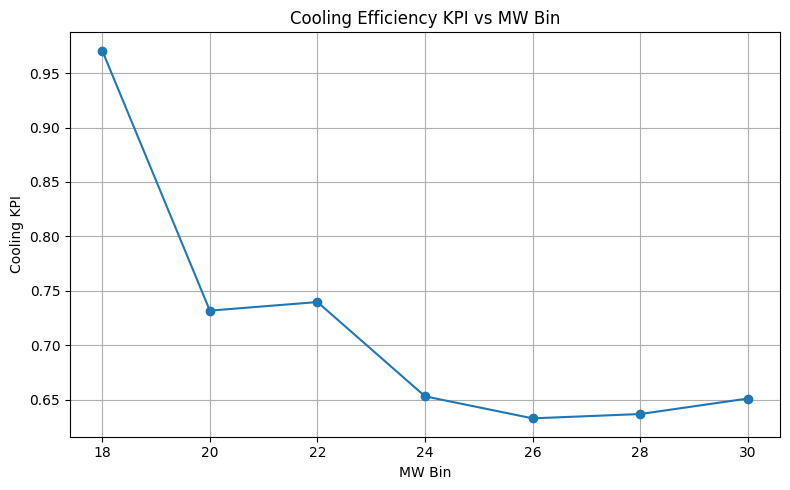

In [75]:
plt.figure(figsize=(8,5))

plt.plot(
    mw_bin_summary["MW_Bin"],
    mw_bin_summary["Cooling_Efficiency_KPI_mean"],
    marker="o"
)

plt.title("Cooling Efficiency KPI vs MW Bin")
plt.xlabel("MW Bin")
plt.ylabel("Cooling KPI")
plt.grid(True)
plt.tight_layout()
plt.show()

In [76]:
plt.figure(figsize=(8,5))

# Check if the column exists before plotting
if "Advanced_Transformer_Health_Score_mean" in mw_bin_summary.columns:
    plt.plot(
        mw_bin_summary["MW_Bin"],
        mw_bin_summary["Advanced_Transformer_Health_Score_mean"],
        marker="o"
    )

    plt.title("Health Score vs MW Bin")
    plt.xlabel("MW Bin")
    plt.ylabel("Health Score")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot 'Health Score vs MW Bin': 'Advanced_Transformer_Health_Score_mean' column is missing from mw_bin_summary.")
    print("Please ensure cell 'nXvDPO8hZGpE' (MW / MVA BIN THERMAL ANALYSIS) is run AFTER cell 'PbUAMP4TZYzj' (ADVANCED HEALTH SCORE) to properly generate 'mw_bin_summary'.")

Cannot plot 'Health Score vs MW Bin': 'Advanced_Transformer_Health_Score_mean' column is missing from mw_bin_summary.
Please ensure cell 'nXvDPO8hZGpE' (MW / MVA BIN THERMAL ANALYSIS) is run AFTER cell 'PbUAMP4TZYzj' (ADVANCED HEALTH SCORE) to properly generate 'mw_bin_summary'.


<Figure size 800x500 with 0 Axes>

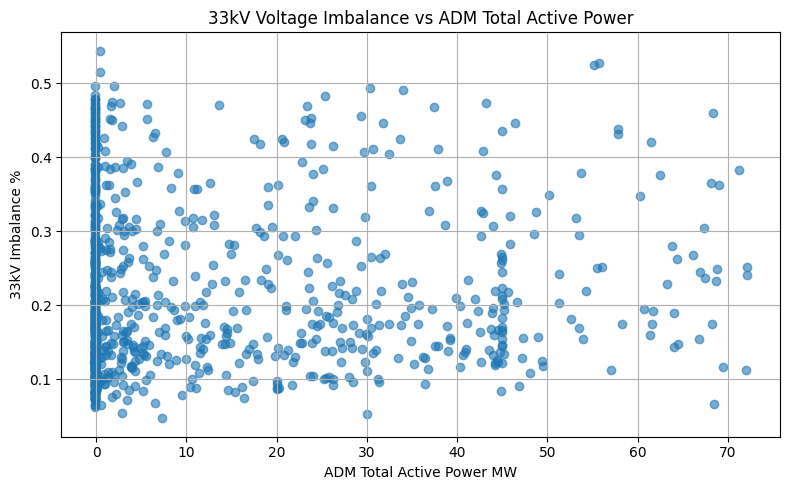

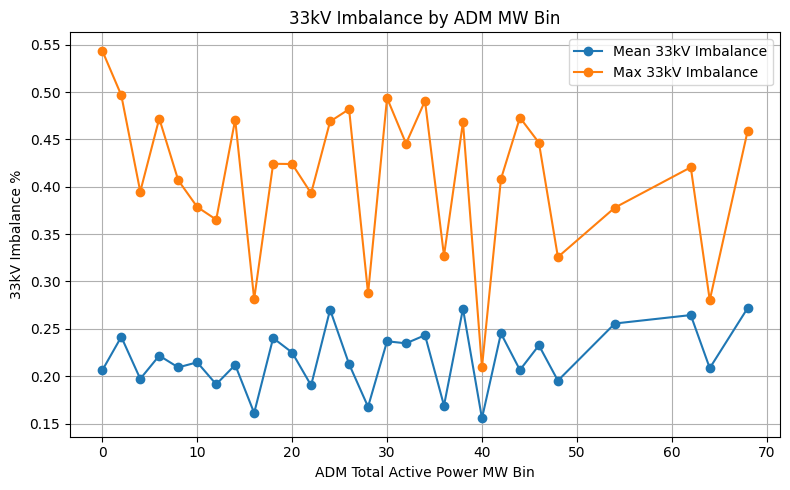

In [80]:
# ============================================================
# PLOT: 33kV Imbalance vs ADM Total Active Power
# ============================================================

plt.figure(figsize=(8,5))
plt.scatter(
    df["ADM_Total_MW"],
    df["LV_33kV_Imbalance_percent"],
    alpha=0.6
)
plt.title("33kV Voltage Imbalance vs ADM Total Active Power")
plt.xlabel("ADM Total Active Power MW")
plt.ylabel("33kV Imbalance %")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(
    adm_imbalance_summary["ADM_MW_Bin"],
    adm_imbalance_summary["LV_33kV_Imbalance_percent_mean"],
    marker="o",
    label="Mean 33kV Imbalance"
)
plt.plot(
    adm_imbalance_summary["ADM_MW_Bin"],
    adm_imbalance_summary["LV_33kV_Imbalance_percent_max"],
    marker="o",
    label="Max 33kV Imbalance"
)
plt.title("33kV Imbalance by ADM MW Bin")
plt.xlabel("ADM Total Active Power MW Bin")
plt.ylabel("33kV Imbalance %")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# 16) EXPORT EXCEL
# ============================================================

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Advanced_Merged_Data", index=False)
    summary.to_excel(writer, sheet_name="Summary", index=False)
    ml_metrics.to_excel(writer, sheet_name="ML_Model_Metrics", index=False)
    fan1.to_excel(writer, sheet_name="Fan_Group_1_Events", index=False)
    fan2.to_excel(writer, sheet_name="Fan_Group_2_Events", index=False)

print(f"\nAdvanced Unit 4 Excel report saved: {output_excel}")


Advanced Unit 4 Excel report saved: Transformer_U4_Advanced_Status_Report.xlsx
